# 1.Importing the technologies

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.signal import find_peaks

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# 2. Loading the video and model paths

In [2]:
video_path = "Bily_1.mp4"
model_path = "hand_landmarker.task"

print("Video path:", video_path)
print("Model path:", model_path)

Video path: Bily_1.mp4
Model path: hand_landmarker.task


In [3]:
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: could not open the video.")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    duration = total_frames / fps

    print("FPS:", fps)
    print("Total frames:", total_frames)
    print("Duration:", duration, "seconds")

cap.release()

FPS: 29.94736842105263
Total frames: 569.0
Duration: 19.0 seconds


# 3. Loading the MediaPipe Hand Landmarker

In [4]:
base_options = python.BaseOptions(model_asset_path=model_path)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1
)

detector = vision.HandLandmarker.create_from_options(options)

print("MediaPipe Hand Landmarker loaded successfully.")

MediaPipe Hand Landmarker loaded successfully.


I0000 00:00:1778416368.674252   11787 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1778416368.678483   11812 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.1), renderer: Mesa Intel(R) Graphics (RPL-S)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1778416368.695552   11789 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778416368.704752   11799 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


# 4. Reading the video frame by frame

In [5]:
cap = cv2.VideoCapture(video_path)

frame_count = 0

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    frame_count += 1

    print("Reading frame:", frame_count)

cap.release()

print("Video reading completed.")

Reading frame: 1
Reading frame: 2
Reading frame: 3
Reading frame: 4
Reading frame: 5
Reading frame: 6
Reading frame: 7
Reading frame: 8
Reading frame: 9
Reading frame: 10
Reading frame: 11
Reading frame: 12
Reading frame: 13
Reading frame: 14
Reading frame: 15
Reading frame: 16
Reading frame: 17
Reading frame: 18
Reading frame: 19
Reading frame: 20
Reading frame: 21
Reading frame: 22
Reading frame: 23
Reading frame: 24
Reading frame: 25
Reading frame: 26
Reading frame: 27
Reading frame: 28
Reading frame: 29
Reading frame: 30
Reading frame: 31
Reading frame: 32
Reading frame: 33
Reading frame: 34
Reading frame: 35
Reading frame: 36
Reading frame: 37
Reading frame: 38
Reading frame: 39
Reading frame: 40
Reading frame: 41
Reading frame: 42
Reading frame: 43
Reading frame: 44
Reading frame: 45
Reading frame: 46
Reading frame: 47
Reading frame: 48
Reading frame: 49
Reading frame: 50
Reading frame: 51
Reading frame: 52
Reading frame: 53
Reading frame: 54
Reading frame: 55
Reading frame: 56
R

# 5. Displaying the video

In [6]:
cap = cv2.VideoCapture(video_path)

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    cv2.imshow("iPhone Video", frame)

    # Press q to quit
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/bilel/miniconda3/envs/ima_med_tg/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bilel/miniconda3/envs/ima_med_tg/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bilel/miniconda3/envs/ima_med_tg/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/bilel/miniconda3/envs/ima_med_tg/lib/python3.10/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDat

# 6. Detecting hand landmarks

In [7]:
cap = cv2.VideoCapture(video_path)

frame_count = 0

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    frame_count += 1

    # Convert BGR to RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Convert to MediaPipe image
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_frame
    )

    # Detect hands
    detection_result = detector.detect(mp_image)

    # Check if a hand exists
    if detection_result.hand_landmarks:

        print(f"Hand detected in frame {frame_count}")

cap.release()

print("Landmark detection completed.")

W0000 00:00:1778416547.811809   11795 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Hand detected in frame 1
Hand detected in frame 2
Hand detected in frame 3
Hand detected in frame 4
Hand detected in frame 5
Hand detected in frame 6
Hand detected in frame 7
Hand detected in frame 8
Hand detected in frame 9
Hand detected in frame 10
Hand detected in frame 11
Hand detected in frame 12
Hand detected in frame 13
Hand detected in frame 14
Hand detected in frame 15
Hand detected in frame 16
Hand detected in frame 17
Hand detected in frame 18
Hand detected in frame 19
Hand detected in frame 20
Hand detected in frame 21
Hand detected in frame 22
Hand detected in frame 23
Hand detected in frame 24
Hand detected in frame 25
Hand detected in frame 26
Hand detected in frame 27
Hand detected in frame 28
Hand detected in frame 29
Hand detected in frame 30
Hand detected in frame 31
Hand detected in frame 32
Hand detected in frame 33
Hand detected in frame 34
Hand detected in frame 35
Hand detected in frame 36
Hand detected in frame 37
Hand detected in frame 38
Hand detected in fram

# 7. Computing the distance signal between thumb and index finger

In [8]:
cap = cv2.VideoCapture(video_path)

distances = []
frames = []

frame_count = 0

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    frame_count += 1

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_frame
    )

    detection_result = detector.detect(mp_image)

    if detection_result.hand_landmarks:

        hand_landmarks = detection_result.hand_landmarks[0]

        # Thumb tip
        thumb_tip = hand_landmarks[4]

        # Index tip
        index_tip = hand_landmarks[8]

        # Coordinates
        x1, y1 = thumb_tip.x, thumb_tip.y
        x2, y2 = index_tip.x, index_tip.y

        # Euclidean distance
        distance = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

        distances.append(distance)
        frames.append(frame_count)

cap.release()

print("Distance signal extracted.")
print("Number of points:", len(distances))

Distance signal extracted.
Number of points: 569


# 8. Plotting the distance signal

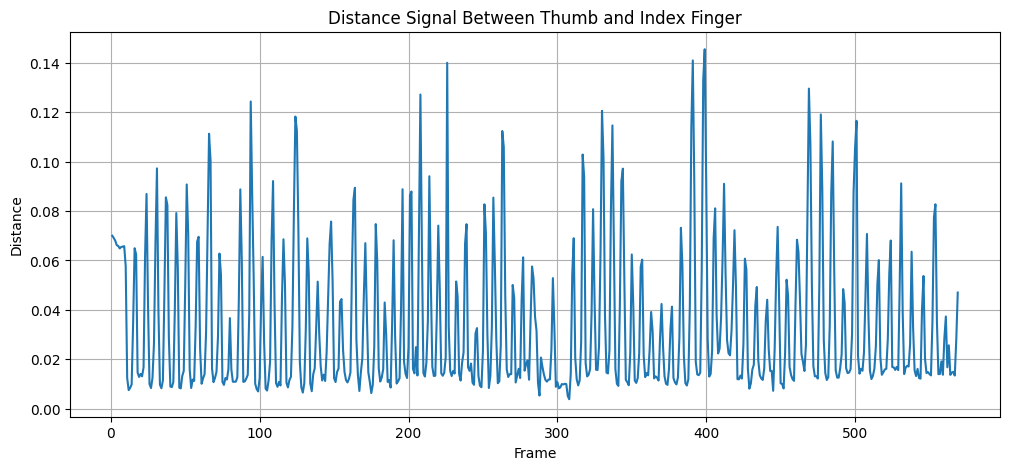

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(frames, distances)

plt.title("Distance Signal Between Thumb and Index Finger")
plt.xlabel("Frame")
plt.ylabel("Distance")

plt.grid(True)
plt.show()

# 9. Detecting finger taps

In [10]:
# Convert to numpy array
signal = np.array(distances)

# Invert signal to detect minima
inverted_signal = -signal

# Detect peaks
peaks, _ = find_peaks(
    inverted_signal,
    distance=5,
    prominence=0.005
)

print("Number of taps detected:", len(peaks))

Number of taps detected: 77


# 10. Visualizing hand landmarks on the video

In [11]:
cap = cv2.VideoCapture(video_path)

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    # Convert BGR → RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # MediaPipe image
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_frame
    )

    # Detect hand
    detection_result = detector.detect(mp_image)

    if detection_result.hand_landmarks:

        hand_landmarks = detection_result.hand_landmarks[0]

        # Thumb tip
        thumb_tip = hand_landmarks[4]

        # Index tip
        index_tip = hand_landmarks[8]

        h, w, _ = frame.shape

        # Convert normalized coordinates to pixels
        thumb_x = int(thumb_tip.x * w)
        thumb_y = int(thumb_tip.y * h)

        index_x = int(index_tip.x * w)
        index_y = int(index_tip.y * h)

        # Draw circles
        cv2.circle(frame, (thumb_x, thumb_y), 10, (0,255,0), -1)
        cv2.circle(frame, (index_x, index_y), 10, (0,0,255), -1)

        # Draw line
        cv2.line(
            frame,
            (thumb_x, thumb_y),
            (index_x, index_y),
            (255,0,0),
            3
        )

    # Show frame
    cv2.imshow("Finger Tapping Analysis", frame)

    # Press q to quit
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

# 11. Visualizing detected finger taps

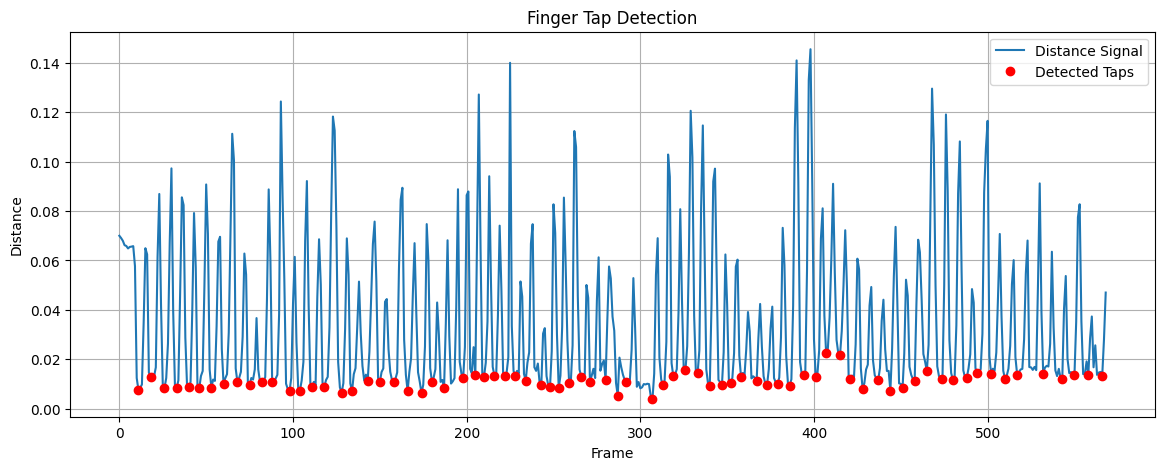

In [12]:
plt.figure(figsize=(14,5))

# Original signal
plt.plot(signal, label="Distance Signal")

# Detected taps
plt.plot(
    peaks,
    signal[peaks],
    "ro",
    label="Detected Taps"
)

plt.title("Finger Tap Detection")
plt.xlabel("Frame")
plt.ylabel("Distance")

plt.legend()
plt.grid(True)

plt.show()

# 12. Extracting biomedical motion features

In [13]:
# Video duration
duration_seconds = duration

# Number of taps
num_taps = len(peaks)

# Tapping speed
speed = num_taps / duration_seconds

# Signal amplitude
amplitude = np.max(signal) - np.min(signal)

# Time intervals between taps
intervals = np.diff(peaks)

# Variability
variability = np.std(intervals)

# Mean interval
mean_interval = np.mean(intervals)

print("===== Finger Tapping Features =====")
print("Video duration:", duration_seconds, "seconds")
print("Number of taps:", num_taps)
print("Tapping speed:", speed, "taps/sec")
print("Amplitude:", amplitude)
print("Mean interval:", mean_interval)
print("Variability:", variability)

===== Finger Tapping Features =====
Video duration: 19.0 seconds
Number of taps: 77
Tapping speed: 4.052631578947368 taps/sec
Amplitude: 0.14157675839249872
Mean interval: 7.302631578947368
Variability: 1.813833805725388


# 13. Saving the processed tracking video

In [14]:
cap = cv2.VideoCapture(video_path)

# Video properties
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Output video
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter(
    "tracked_output.mp4",
    fourcc,
    fps,
    (width, height)
)

tap_counter = 0
peak_index = 0

frame_count = 0

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    frame_count += 1

    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_frame
    )

    detection_result = detector.detect(mp_image)

    if detection_result.hand_landmarks:

        hand_landmarks = detection_result.hand_landmarks[0]

        thumb_tip = hand_landmarks[4]
        index_tip = hand_landmarks[8]

        h, w, _ = frame.shape

        thumb_x = int(thumb_tip.x * w)
        thumb_y = int(thumb_tip.y * h)

        index_x = int(index_tip.x * w)
        index_y = int(index_tip.y * h)

        # Draw circles
        cv2.circle(frame, (thumb_x, thumb_y), 10, (0,255,0), -1)
        cv2.circle(frame, (index_x, index_y), 10, (0,0,255), -1)

        # Draw line
        cv2.line(
            frame,
            (thumb_x, thumb_y),
            (index_x, index_y),
            (255,0,0),
            3
        )

    # Count taps
    if peak_index < len(peaks):

        if frame_count == peaks[peak_index]:

            tap_counter += 1
            peak_index += 1

    # Display tap counter
    cv2.putText(
        frame,
        f"Taps: {tap_counter}",
        (30,50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,255),
        3
    )

    # Write frame
    out.write(frame)

cap.release()
out.release()

print("Processed video saved as tracked_output.mp4")

Processed video saved as tracked_output.mp4
